# Исследование надежности заемщиков


Заказчик — кредитный отдел банка. Нужно разобраться, влияет ли семейное положение и количество детей клиента на факт погашения кредита в срок. Входные данные от банка — статистика о платёжеспособности клиентов.

Результаты исследования будут учтены при построении модели кредитного скоринга — специальной системы, которая оценивает способность потенциального заёмщика вернуть кредит банку.

Описание данных:
- children — количество детей в семье
- days_employed — общий трудовой стаж в днях
- dob_years — возраст клиента в годах
- education — уровень образования клиента
- education_id — идентификатор уровня образования
- family_status — семейное положение
- family_status_id — идентификатор семейного положения
- gender — пол клиента
- income_type — тип занятости
- debt — имел ли задолженность по возврату кредитов
- total_income — ежемесячный доход
- purpose — цель получения кредита

Во второй части проекта вы выполните шаги 3 и 4. Их вручную проверит ревьюер.
Чтобы вам не пришлось писать код заново для шагов 1 и 2, мы добавили авторские решения в ячейки с кодом. 



## Откройте таблицу и изучите общую информацию о данных

**Задание 1. Импортируйте библиотеку pandas. Считайте данные из csv-файла в датафрейм и сохраните в переменную `data`. Путь к файлу:**

`/datasets/data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


try:
    data = pd.read_csv('/datasets/data.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

**Задание 2. Выведите первые 20 строчек датафрейма `data` на экран.**

In [2]:
data.head(20)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу
5,0,-926.185831,27,высшее,0,гражданский брак,1,M,компаньон,0,255763.565419,покупка жилья
6,0,-2879.202052,43,высшее,0,женат / замужем,0,F,компаньон,0,240525.971920,операции с жильем
7,0,-152.779569,50,СРЕДНЕЕ,1,женат / замужем,0,M,сотрудник,0,135823.934197,образование
8,2,-6929.865299,35,ВЫСШЕЕ,0,гражданский брак,1,F,сотрудник,0,95856.832424,на проведение свадьбы
9,0,-2188.756445,41,среднее,1,женат / замужем,0,M,сотрудник,0,144425.938277,покупка жилья для семьи


**Задание 3. Выведите основную информацию о датафрейме с помощью метода `info()`.**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


## Предобработка данных

### Удаление пропусков

**Задание 4. Выведите количество пропущенных значений для каждого столбца. Используйте комбинацию двух методов.**

In [4]:
data.isna().sum()

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64

**Задание 5. В двух столбцах есть пропущенные значения. Один из них — `days_employed`. Пропуски в этом столбце вы обработаете на следующем этапе. Другой столбец с пропущенными значениями — `total_income` — хранит данные о доходах. На сумму дохода сильнее всего влияет тип занятости, поэтому заполнить пропуски в этом столбце нужно медианным значением по каждому типу из столбца `income_type`. Например, у человека с типом занятости `сотрудник` пропуск в столбце `total_income` должен быть заполнен медианным доходом среди всех записей с тем же типом.**

In [5]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['total_income'].isna()), 'total_income'] = \
    data.loc[(data['income_type'] == t), 'total_income'].median()

### Обработка аномальных значений

**Задание 6. В данных могут встречаться артефакты (аномалии) — значения, которые не отражают действительность и появились по какой-то ошибке. таким артефактом будет отрицательное количество дней трудового стажа в столбце `days_employed`. Для реальных данных это нормально. Обработайте значения в этом столбце: замените все отрицательные значения положительными с помощью метода `abs()`.**

In [6]:
data['days_employed'] = data['days_employed'].abs()

**Задание 7. Для каждого типа занятости выведите медианное значение трудового стажа `days_employed` в днях.**

In [7]:
data.groupby('income_type')['days_employed'].agg('median')

income_type
безработный        366413.652744
в декрете            3296.759962
госслужащий          2689.368353
компаньон            1547.382223
пенсионер          365213.306266
предприниматель       520.848083
сотрудник            1574.202821
студент               578.751554
Name: days_employed, dtype: float64

У двух типов (безработные и пенсионеры) получатся аномально большие значения. Исправить такие значения сложно, поэтому оставьте их как есть. Тем более этот столбец не понадобится вам для исследования.

**Задание 8. Выведите перечень уникальных значений столбца `children`.**

In [8]:
data['children'].unique()

array([ 1,  0,  3,  2, -1,  4, 20,  5])

**Задание 9. В столбце `children` есть два аномальных значения. Удалите строки, в которых встречаются такие аномальные значения из датафрейма `data`.**

In [9]:
data = data[(data['children'] != -1) & (data['children'] != 20)]

**Задание 10. Ещё раз выведите перечень уникальных значений столбца `children`, чтобы убедиться, что артефакты удалены.**

In [10]:
data['children'].unique()

array([1, 0, 3, 2, 4, 5])

### Удаление пропусков (продолжение)

**Задание 11. Заполните пропуски в столбце `days_employed` медианными значениями по каждого типа занятости `income_type`.**

In [11]:
for t in data['income_type'].unique():
    data.loc[(data['income_type'] == t) & (data['days_employed'].isna()), 'days_employed'] = \
    data.loc[(data['income_type'] == t), 'days_employed'].median()

**Задание 12. Убедитесь, что все пропуски заполнены. Проверьте себя и ещё раз выведите количество пропущенных значений для каждого столбца с помощью двух методов.**

In [12]:
data.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

### Изменение типов данных

**Задание 13. Замените вещественный тип данных в столбце `total_income` на целочисленный с помощью метода `astype()`.**

In [13]:
data['total_income'] = data['total_income'].astype(int)

### Обработка дубликатов

**Задание 14. Обработайте неявные дубликаты в столбце `education`. В этом столбце есть одни и те же значения, но записанные по-разному: с использованием заглавных и строчных букв. Приведите их к нижнему регистру. Проверьте остальные столбцы.**

In [14]:
data['education'] = data['education'].str.lower()

**Задание 15. Выведите на экран количество строк-дубликатов в данных. Если такие строки присутствуют, удалите их.**

In [15]:
data.duplicated().sum()

71

In [16]:
data = data.drop_duplicates()

### Категоризация данных

**Задание 16. На основании диапазонов, указанных ниже, создайте в датафрейме `data` столбец `total_income_category` с категориями:**

- 0–30000 — `'E'`;
- 30001–50000 — `'D'`;
- 50001–200000 — `'C'`;
- 200001–1000000 — `'B'`;
- 1000001 и выше — `'A'`.


**Например, кредитополучателю с доходом 25000 нужно назначить категорию `'E'`, а клиенту, получающему 235000, — `'B'`. Используйте собственную функцию с именем `categorize_income()` и метод `apply()`.**

In [17]:
def categorize_income(income):
    try:
        if 0 <= income <= 30000:
            return 'E'
        elif 30001 <= income <= 50000:
            return 'D'
        elif 50001 <= income <= 200000:
            return 'C'
        elif 200001 <= income <= 1000000:
            return 'B'
        elif income >= 1000001:
            return 'A'
    except:
        pass

In [18]:
data['total_income_category'] = data['total_income'].apply(categorize_income)

**Задание 17. Выведите на экран перечень уникальных целей взятия кредита из столбца `purpose`.**

In [19]:
data['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

**Задание 18. Создайте функцию, которая на основании данных из столбца `purpose` сформирует новый столбец `purpose_category`, в который войдут следующие категории:**

- `'операции с автомобилем'`,
- `'операции с недвижимостью'`,
- `'проведение свадьбы'`,
- `'получение образования'`.

**Например, если в столбце `purpose` находится подстрока `'на покупку автомобиля'`, то в столбце `purpose_category` должна появиться строка `'операции с автомобилем'`.**

**Используйте собственную функцию с именем `categorize_purpose()` и метод `apply()`. Изучите данные в столбце `purpose` и определите, какие подстроки помогут вам правильно определить категорию.**

In [20]:
def categorize_purpose(row):
    try:
        if 'автом' in row:
            return 'операции с автомобилем'
        elif 'жил' in row or 'недвиж' in row:
            return 'операции с недвижимостью'
        elif 'свад' in row:
            return 'проведение свадьбы'
        elif 'образов' in row:
            return 'получение образования'
    except:
        return 'нет категории'

In [21]:
data['purpose_category'] = data['purpose'].apply(categorize_purpose)

### Шаг 3. Исследуйте данные и ответьте на вопросы

#### 3.1 Есть ли зависимость между количеством детей и возвратом кредита в срок?

In [22]:
# рассчитаем процент невозврата долга отдельно по всем заемщикам, заемщикам с детьми и заемщикам без детей
default_ratio = data['debt'].sum() / data['debt'].count()
default_ratio_kids = data.loc[data['children'] > 0, 'debt'].sum() / data.loc[data['children'] > 0, 'debt'].count()
default_ratio__single = data.loc[data['children'] == 0, 'debt'].sum() / data.loc[data['children'] == 0, 'debt'].count()

print(f'Процент просрочек по всем заемщикам: {default_ratio:.2%}')
print(f'Процент просрочек по заемщикам с детьми: {default_ratio_kids:.2%}')
f'Процент просрочек по заемщикам без детей: {default_ratio__single:.2%}'

Процент просрочек по всем заемщикам: 8.12%
Процент просрочек по заемщикам с детьми: 9.24%


'Процент просрочек по заемщикам без детей: 7.54%'

In [23]:
# напишем функция для построения сводных таблиц со статистикой по просрочкам в разрезе по категориям из выбранной колонки
def make_pivot_table(data, groupby, column='debt', agg=['count', 'sum', 'mean']):
    pivot_table = data.groupby(groupby)[column].agg(agg)
    try:
        pivot_table['mean'] =  pivot_table['mean'] * 100
        pivot_table['Доля наблюдений, %'] = pivot_table['count'] / len(data) * 100
        pivot_table['Доля наблюдений, %'] =  pivot_table['Доля наблюдений, %'].round(2).astype(str)
        rename_dict = {
            'count' : 'Количество наблюдений',
            'sum' : 'Количество просрочек',
            'mean' : 'Процент просрочек, %',
            'median' : 'Медиана',
            'max' : 'Максимум',
            'min' : 'Минимум'
        }
        pivot_table = pivot_table.rename(columns=rename_dict)
    except:
        pass
    return pivot_table

In [24]:
# рассчитаем средний процент просрочки в разрезе по количеству детей у заемщиков
kids_debt_relation = make_pivot_table(data, 'children')
kids_debt_relation 

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
children,,,,
0,14091,1063,7.543822,66.06
1,4808,444,9.234609,22.54
2,2052,194,9.454191,9.62
3,330,27,8.181818,1.55
4,41,4,9.756098,0.19
5,9,0,0.000000,0.04


In [25]:
# напишем функцию для построения bar plot, показывающему зависимость просрочки по выбранному признаку 
def make_bar_plot(data):
    # Извлечение данных из DataFrame
    x_values = data.index
    y_values = data['Процент просрочек, %'].values
    
    # Создание фигуры с заданными размерами
    plt.figure(figsize=(15, 5))
    
    # Построение графика
    plt.bar(x_values, y_values)
    plt.xlabel('Категории')
    plt.ylabel('Значения просрочки')
    plt.title(f'График просрочек в разрезе по колонке: {data.index.name}')
    plt.grid(True)
    
    # Форматирование вертикальной оси в процентах с двумя знаками после запятой
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    
    # Отображение графика
    return plt.show()

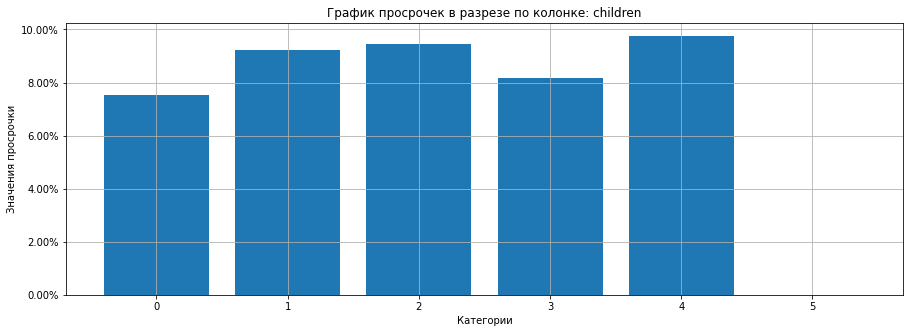

In [26]:
make_bar_plot(kids_debt_relation)

In [27]:
# выведем общее число наблюдений в выборки
f'Общее число наблюдений в выборке: {len(data)}'

'Общее число наблюдений в выборке: 21331'

**Вывод:**

По результатам исследования могут быть сделаны следующие выводы:

- Процент просрочек по кредитам у заемщиков с детьми (9.24%) в среднем больше, чем аналогичный показатель у заемщиков без детей (7.54%). Это свидетельствует о наличии прямой связи между числом просрочек и наличием детей у заемщика.
- Процент просрочек у семей с двумя детьми (9.45%) немного выше чем у семей с одним ребенком (9.23%).
- Средний уровень задолженности у заемщиков с тремя детьми (8.18%) немного ниже, чем у заемщиков с одним и двумя детьми. Заемщики с четырьмя детьми имеют самый высокий средний уровень просрочек (9.76%) среди всех категорий. При этом, общее количество заемщиков с тремя (330) и четыремя (41) детьми невелико по сравнению с общим размером выборки (21331), т.е. составляют менее 2% от общего числа наблюдений. Учитывая, что значения просрочек по группам с тремя и четыремя детьми близки к значениям по другим группам и не демонстрируют явной тенденции к увеличению или уменьшению просрочки с ростом количества детей, то такие различия могут быть объяснены возможными искажениями ввиду небольшого числа наблюдений.
- Заемщики с пятью детьми не имеют просрочек по кредитам (mean = 0.00%), но это может быть результатом очень маленького размера выборки (всего 9 человек).

Таким образом, заемщики с детьми в среднем чаще допускают просрочку по кредитам, чем заемщики без детей. При этом количество детей существенно не влияет на вероятность допущения просрочки по кредитам у заемщиков с детьми. В отношении заемщиков с большими семьями (3 и более детей), результаты исследования могут быть искажены ввиду небольшого количества наблюдений в выборке по данным группам (<2%).


#### 3.2 Есть ли зависимость между семейным положением и возвратом кредита в срок?

In [28]:
# посмотрим общую статистику просрочек по типам семейного положения и отсротируем таблицу по значению mean (по убыванию)
family_debt_relation = make_pivot_table(data, 'family_status', 'debt').sort_values(by='Процент просрочек, %',ascending=False)
family_debt_relation

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
family_status,,,,
Не женат / не замужем,2796,273,9.763948,13.11
гражданский брак,4134,385,9.313014,19.38
женат / замужем,12261,927,7.560558,57.48
в разводе,1189,84,7.064760,5.57
вдовец / вдова,951,63,6.624606,4.46


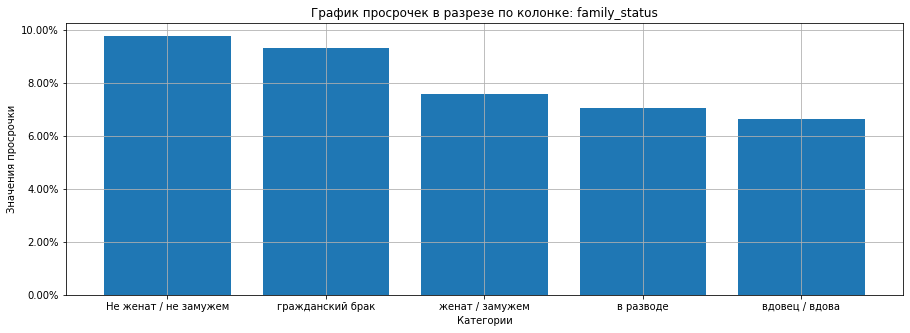

In [29]:
make_bar_plot(family_debt_relation)

На графике видим, что существует зависимость просрочек платежей по кредитам от семейного положения заемщиков. Неженатые/незамужние в среднем допускают больше всего просрочек (9.76%), а вдовцы/вдовы меньше всего (6,62%). При этом люди в гражданском браке, как правило, допускают больше просрочек (9.31%) чем женатые/замужние(7.56%) и чем люди в разводе (7.06%).

1. Заметим, что больше всего и меньше всего просрочек допускают одинокие люди, что неожиданно. Проверим есть ли связь между тем одинок человек или в паре, с вероятностью допущения им просрочки.

2. Обратим также внимание на то, что семейные положения, расположенные на графике в порядке убывания вероятности проскочки по займам, внешне напоминают этапы формирования и становления семьи: неженатый/незамужний молодой человек вступает в незарегистрированные отношения (гражданский брак), который со временем перерастает в официальный брак, который заканчивается разводом или смертью одного из супругов. В связи с этим можно предположить, что существует определенная зависимость между семейным положением и возрастом заемщика. Проверим, существует ли обратная зависимость между этапами развития семейных отношений (описанным выше) и возрастом заемщика.

Для начала проверим связь между наличием/отсутствием отношений у человека с вероятностью допущения просрочки по займу

In [30]:
# создание и вывод словаря семейного статуса и id
family_dict = data[['family_status', 'family_status_id']]
family_dict = family_dict.drop_duplicates().reset_index(drop=True)
family_dict

,family_status,family_status_id
0,женат / замужем,0
1,гражданский брак,1
2,вдовец / вдова,2
3,в разводе,3
4,Не женат / не замужем,4


In [31]:
# функиця для разбивки на категории заемщиков (одиночки и парочки)
def is_alone(family_status):
    try:
        if family_status < 2:
            return False
        elif 2 <= family_status <= 5:
            return True
    except:
        return 'status unknown'

In [32]:
# разбивка заемщиков на одиночки и парочки, запись значения категории в колонку is_alone, проверка результатов операции
data['is_alone'] = data['family_status_id'].apply(is_alone)
data['is_alone'].unique()

array([False,  True])

In [33]:
alone_debt_relation = make_pivot_table(data, 'is_alone').sort_values(by='Процент просрочек, %', ascending=False)
alone_debt_relation.index = ['Одиночки', 'Парочки']
alone_debt_relation

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
Одиночки,4936,420,8.508914,23.14
Парочки,16395,1312,8.002440,76.86


Из таблицы можно сделать вывод, что большинство (76%) заемщиков состоят в отношениях. При этом одиночки немного чаще допускаю просрочки платежей, чем люди в отношениях (8.5% и 8.0%, соответственно).

Далее проверим связь между этапами развития семейных отношений (описаны выше) и возрастом заемщика.

In [34]:
family_age_relation = make_pivot_table(data, groupby='family_status', column='dob_years', agg=['count', 'mean', 'median']).sort_values(by='Процент просрочек, %')
family_age_relation['Процент просрочек, %'] /= 100
family_age_relation = family_age_relation.rename(columns={'Процент просрочек, %' : 'Средний возраст'})
family_age_relation

,Количество наблюдений,Средний возраст,Медиана,"Доля наблюдений, %"
family_status,,,,
Не женат / не замужем,2796,38.368026,36,13.11
гражданский брак,4134,42.067731,41,19.38
женат / замужем,12261,43.558519,43,57.48
в разводе,1189,45.561817,46,5.57
вдовец / вдова,951,56.501577,58,4.46


In [35]:
# отформатируем обе таблицы и объединим их в новую с названием family_mean_debt_age
family_mean_debt = family_debt_relation.drop(['Количество наблюдений', 'Количество просрочек', 'Доля наблюдений, %'], axis = 1)
family_mean_age = family_age_relation.drop(['Количество наблюдений', 'Медиана', 'Доля наблюдений, %'], axis = 1)

family_mean_debt_age = family_mean_debt.merge(family_mean_age, on='family_status')

family_mean_debt_age

,"Процент просрочек, %",Средний возраст
family_status,,
Не женат / не замужем,9.763948,38.368026
гражданский брак,9.313014,42.067731
женат / замужем,7.560558,43.558519
в разводе,7.064760,45.561817
вдовец / вдова,6.624606,56.501577


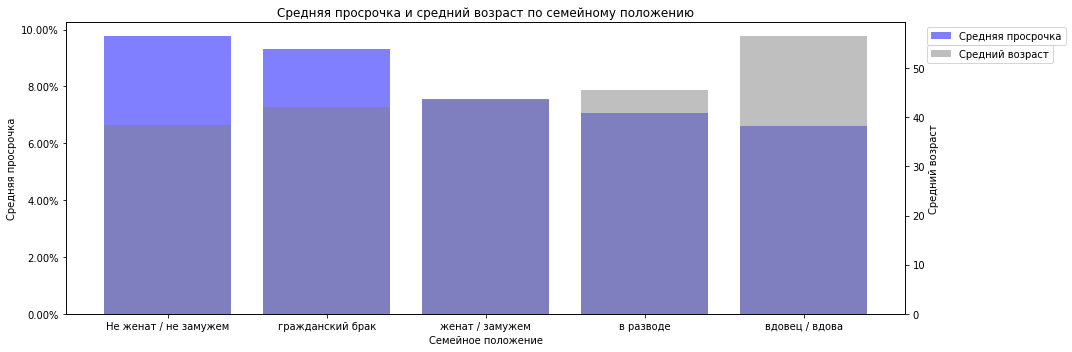

In [36]:
# Построим график
def make_family_age(table):
    # Данные из таблицы
    family_status = table.index
    mean_debt_values = table['Процент просрочек, %'].to_list()
    mean_age_values = table['Средний возраст'].to_list()

    # Создание графика
    fig, ax1 = plt.subplots(figsize=(15, 5))  # Изменение размера рисунка
    
    # Первая ось (слева) - mean_debt
    ax1.set_xlabel('Семейное положение')
    ax1.set_ylabel('Средняя просрочка')
    ax1.bar(family_status, mean_debt_values, color='blue', alpha=0.5)  # Полупрозрачный график
    ax1.tick_params(axis='y')
    
    # Вторая ось (справа) - mean_age
    ax2 = ax1.twinx()
    ax2.set_ylabel('Средний возраст')
    ax2.bar(family_status, mean_age_values, color='gray', alpha=0.5)  # Полупрозрачный график
    ax2.tick_params(axis='y')
    
    # Форматирование левой оси в процентах с двумя знаками после запятой
    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.2f}%'))
    
    # Добавление легенды за границы графика
    ax1.legend(['Средняя просрочка'], loc='upper left', bbox_to_anchor=(1.02, 1))
    ax2.legend(['Средний возраст'], loc='upper left', bbox_to_anchor=(1.02, 0.94))

    # Настройка внешнего вида графика
    plt.title('Средняя просрочка и средний возраст по семейному положению')
    plt.tight_layout()
    
    # Отображение графика
    return plt.show()
    
make_family_age(family_mean_debt_age)

На графике видно, что разница в возрасте между женатыми/замужними (43.56 лет) и заемщиками в гражданском браке (42.07 лет), невелика. При этом, процент просрочек по кредитам у первых (7.56%) существенно ниже, чем у вторых (9.31%). Из этого можно предположить, что заемщики, которые предпочитают официально оформить свои отношения, более ответственно подходят к погашению обязательств по кредитам, чем те, кто находится в незарегистрированных отношениях. 

График также показывает, что предположение о наличии обратной зависимости между семейным положением и возрастом заемщиков в выборке подтвердилось. Это может свидетельствовать о том, что с возрастом, заемщики обладают более высоким уровнем финансовой независимости и, следовательно, лучше погашают займы. 

Проверим это предположение, разбив выборку на категории по возрасту (с шагом 10 лет) и посмотрим процент допущенных просрочек в каждой группе.

In [37]:
age_labels = ['до 30', 'от 30 до 40', 'от 40 до 50', 'от 50 до 60', 'от 60 до 70', 'старше 70']
age_bins = [0, 30, 40, 50, 60, 70, float('inf')]
data['age_group'] = pd.cut(data['dob_years'], bins=age_bins, labels=age_labels, right=False)

In [38]:
# посмотрим на возраста заемщиков в выборке
data['dob_years'].sort_values().unique()

array([ 0, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75])

Заметим, что в выборке есть заемщики с возрастом 0 лет. Оценим их количество:

In [39]:
data.loc[data['dob_years'] == 0, 'dob_years'].count()

100

In [40]:
'{:.2%}'.format(data.loc[data['dob_years'] == 0, 'dob_years'].count() / len(data))

'0.47%'

Нулевых значений относительно немного (<1% выборки). Однако, чтобы аномальные значения не искажали результат сравнения, удалим строки с нулевыми значеними dob_years:

In [41]:
# Удалим строки с нулевыми значеними dob_years
data_adjusted_age = data[data['dob_years'] != 0]
# Проверим количество нулевых значения
data_adjusted_age.loc[data_adjusted_age['dob_years'] == 0]['dob_years'].count()

0

In [42]:
# сгруппируем таблицу по категориям возраста, посчитаем среднее значение просрочки для каждой группы.
age_debt_relation = make_pivot_table(data_adjusted_age, 'age_group').sort_values(by='Процент просрочек, %', ascending=False)
age_debt_relation

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
age_group,,,,
до 30,3166,349,11.023373,14.91
от 30 до 40,5625,548,9.742222,26.49
от 40 до 50,5318,401,7.540429,25.05
от 50 до 60,4631,303,6.542863,21.81
от 60 до 70,2322,117,5.038760,10.94
старше 70,169,6,3.550296,0.8


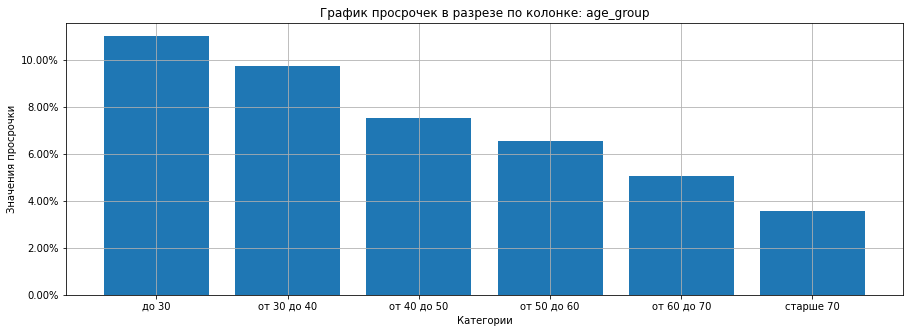

In [43]:
# Для наглядности построим график зависимости процента просрочки от возраста
make_bar_plot(age_debt_relation)

Предположение о том, что с возрастом заемщики обладают более высоким уровнем финансовой независимости и, следовательно, лучше погашают займы подтвержается.

**Вывод:** 

По результатам исследования могут быть сделаны следующие выводы:
1. Вероятность допущения просрочки по займам зависит от семейного положения заемщика. Неженатые/незамужние в среднем допускают больше всего просрочек (9.76%), а вдовцы/вдовы меньше всего (6,62%). Группы заемщиков с различным сеймейным статусом могут быть упорядочены в порядке убывания процента допущенных ими просрочек следующим образом:
    - не женат / не замужем
    - гражданский брак
    - женат / замужем
    - в разводе
    - вдовец / вдова
2. Заметим, что существует обратная зависимость между семейным положением заемщика (в порядке указанном выше) и его возрастом. Зависимость между возрастом заемщика и процентом просрочек более явная и носит линейный характер. Поэтому, такое расположение и порядок следования семейных положений могут быть обусловлены преимущественно средним возрастом заемщика в каждой из групп, а не его семейным положением. При этом семейное положение также вносит определенные коррективы и влияет на вероятность допущения просрочки по кредитам. Так, например:
    - Заемщики, которые предпочитают официально оформлять свои отношения в браке, более ответственно подходят к погашению обязательств по кредитам и реже допускают просрочки по платежам, чем те, которые находятся в незарегистрированных отношениях. Проценты просрочек у данных групп составляют 7.56% и 9.31%, соответственно.
    - Одинокие люди в среднем чаще допускаю просрочки платежей, чем люди, находящиеся в отношениях. Проценты просрочек у данных групп составляют 8.5% и 8.0%, соответственно.

#### 3.3 Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

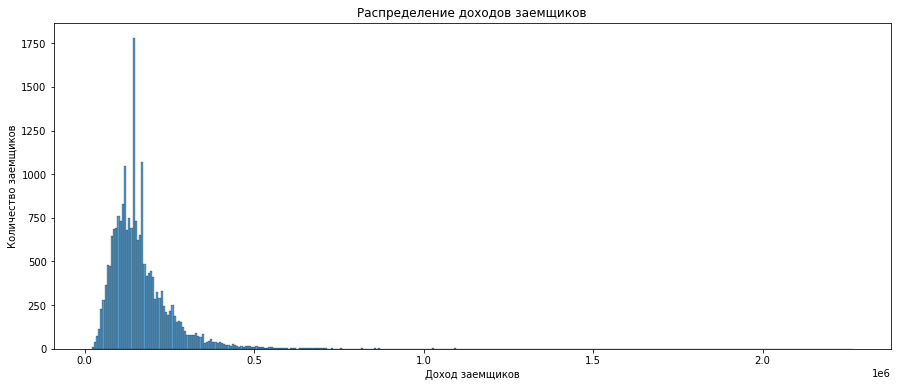

In [44]:
# наглядно оценим общее распределение доходов у заемщиков c помощью гистограммы
def plot_income_histogram(data):
    # Создаем новую фигуру с заданным размером
    plt.figure(figsize=(15, 6))
    
    # Используем Seaborn для построения гистограммы
    sns.histplot(data)

    # Настройка осей и заголовка
    plt.xlabel('Доход заемщиков')
    plt.ylabel('Количество заемщиков')
    plt.title('Распределение доходов заемщиков')

    # Показываем гистограмму
    return plt.show()

plot_income_histogram(data['total_income'])

In [45]:
# сгруппируем таблицу по категориям доходов, посчитаем среднее значение просрочки для каждой группы.
income_debt_relation = make_pivot_table(data, 'total_income_category')
income_debt_relation

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
total_income_category,,,,
A,25,2,8.000000,0.12
B,5014,354,7.060231,23.51
C,15921,1353,8.498210,74.64
D,349,21,6.017192,1.64
E,22,2,9.090909,0.1


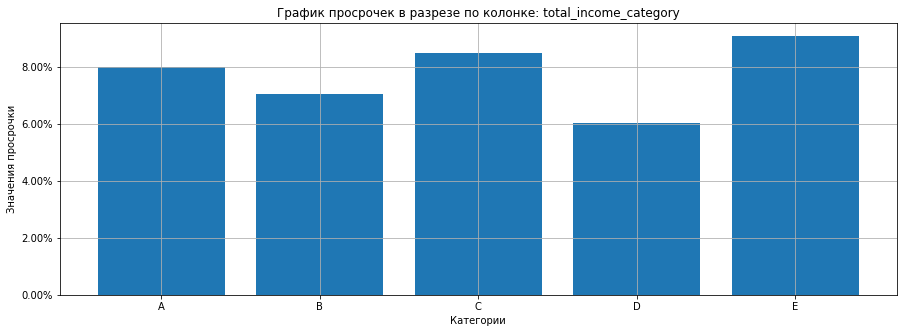

In [46]:
# Для наглядности построим график зависимости процента просрочки от категории доходов
make_bar_plot(income_debt_relation)

Абсолютное большинство заемщиков сосредоточено в **Группе B** (23.51%) и **Группе C** (74.64%) и имеют доход в диапазоне от 50 до 200 тыс. рублей. Число заемщиков из **Групп A, D, E** совокупно составляет менее 2% общего числа заемщиков, что может влиять на достоверность полученных результатов по данным группам.

Наименьший процент просрочек по кредитам имеется в **Группе D** (6.02%), наибольший процент просрочек наблюдается у заемщиков из наименее обеспеченной **Группы E**. Обе эти группы представляют наименее обеспеченные категории заемщиков. Причины расхождения значений просрочек по займам между двумя группами с наименьшими доходами неочевидны, особенно учитывая, что у категорий с большим уровнем дохода процент просрочек снова возрастает.

График зависимости вероятности просрочки от категории дохода заемщика в данном разрезе также не позволяет установить наличие явной зависимости между значениями всех пяти категорий дохода. 

При этом заметим, что практически **98%** заемщиков распределены всего в рамках двух категорий **B** и **С** и если рассматривать эти две категории отдельно, то категория заемщиков с более высоким доходом имеет меньший размер просрочки про кредитам. Это обстоятельство может также косвенно свидетельствовать о том, что зависимость между уровнем дохода и вероятностью просрочки все таки есть, а значения по иным группам содержат погрешности ввиду того, что основаны на небольшом количестве наблюдений. 

Чтобы убедиться, что зависимость все таки имеется, можно разбить выборку на большее количество групп по доходам, и посмотреть, обнаруживается ли эта тенденция при более детальном приближении.

In [47]:
# поделим всю выборку по доходу на 10 категорий с примерно равным количеством наблюдений
data['total_income_detailed_category'] = pd.qcut(data['total_income'], 10, labels=False)

In [48]:
# выведем границы интервалов доходов для получившихся Групп:
income_categories = pd.qcut(data['total_income'], 10).value_counts().sort_index().index
income_intervals = [str(income_intervals) for income_intervals in income_categories]
income_intervals

['(20666.999, 78710.0]',
 '(78710.0, 98514.0]',
 '(98514.0, 115973.0]',
 '(115973.0, 132113.0]',
 '(132113.0, 142594.0]',
 '(142594.0, 161380.0]',
 '(161380.0, 179844.0]',
 '(179844.0, 214604.0]',
 '(214604.0, 269801.0]',
 '(269801.0, 2265604.0]']

In [67]:
# КОД РЕВЬЮЕРА
data['new_income_category'] = pd.qcut(data['total_income'], q=5, 
                                      labels = ['очень низкий','низкий','средний','высокий','очень высокий'])
data_income = data.groupby('new_income_category').agg({'debt':['count', 'mean'], 'total_income':['min', 'max']})
data_income.columns = ['Кол-во клиентов', 'Доля невозврата', 'Минимальный доход', 'Максимальный доход']
data_income

,Кол-во клиентов,Доля невозврата,Минимальный доход,Максимальный доход
new_income_category,,,,
очень низкий,4267,0.080619,20667,98514
низкий,4266,0.083919,98522,132113
средний,4266,0.087436,132115,161380
высокий,4266,0.083919,161386,214604
очень высокий,4266,0.070089,214609,2265604


In [49]:
# сгруппируем таблицу по категориям доходов, посчитаем среднее значение просрочки для каждой группы.
income_debt_relation_detailed = make_pivot_table(data, 'total_income_detailed_category')
income_debt_relation_detailed

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
total_income_detailed_category,,,,
0,2134,157,7.357076,10.0
1,2133,187,8.766995,10.0
2,2133,178,8.345054,10.0
3,2133,180,8.438819,10.0
4,2250,205,9.111111,10.55
5,2016,168,8.333333,9.45
6,2133,179,8.391936,10.0
7,2133,179,8.391936,10.0
8,2133,148,6.938584,10.0


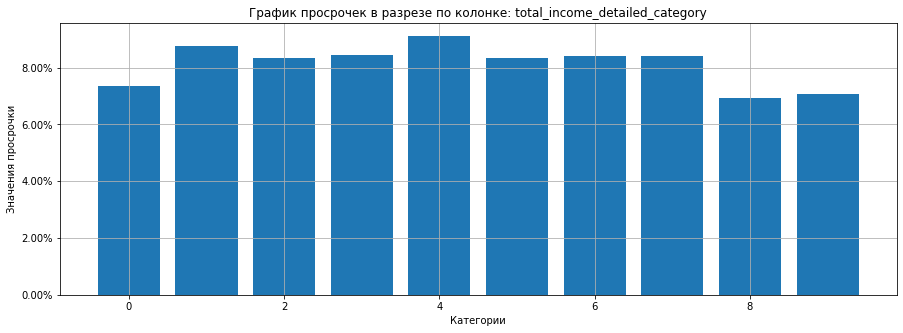

In [50]:
make_bar_plot(income_debt_relation_detailed)

На графике видно, что сотрудники с очень низким (**Группа 0** с доходом до 78710 тыс. руб.) и очень высоким доходом (**Группы 8-9** с доходом более 214604 тыс. руб.) значительно реже допускают просрочки по займам, чем остальные.

**Группы 1-7** (доход от 78710 до 214604 тыс. руб.) допускают просрочки с примерно одинаковым постоянством. На графике видно, что **Группы 1 и 4** немного выбиваются из общей картины и процент просрочки по ним немного больше, чем по остальным группам. Учитывая то, что в ходе исследования были обнаружена статистическая аномалия на границах **Групп 4 и 5** (большое количество работников с одинаковой суммой зарплаты), можно предположить, что отклонения связаны с другими факторами (например, неоднородностью данных, задержкой выплат зарплат крупным работодателем, техническими ошибками в данных и т.д.), а не величиной дохода заемщика. 

In [51]:
# средний размер просрочки среди Групп 0,8,9
data.loc[(data['total_income'] <= 78710) | (data['total_income'] > 214604)]['debt'].mean()

0.07125

In [52]:
# средний размер просрочки среди Групп 1-7
data.loc[(data['total_income'] > 78710) & (data['total_income'] <= 214604)]['debt'].mean()

0.08545978166231331

Заметим, что Группа 4 и Группа 5 получились нестандартного размера (10.55% и 9.45%, вместо 10.0%). Возможно на границу группы или рядом с ней попадают заемщики с большим количеством одинаковых зарплат. Выясним это, посчитав количество зарплат с пограничным значением, равным 142594 рублей.

In [53]:
#посчитаем количество сотрудников с зарплатой ровно 142594 рублей
data.loc[data['total_income'] == 142594]['total_income'].count()

1066

In [54]:
# выразим количество работников, получающих данную зарплату, в процентном отношении от общего числа рабочих
data.loc[data['total_income'] == 142594]['total_income'].count()/len(data)*100

4.997421592986733

In [55]:
# отразим 5 первых строк таблицы data с такой зарплатой:
data.loc[data['total_income'] == 142594].head()

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose,total_income_category,purpose_category,is_alone,age_group,total_income_detailed_category
82,2,1572.328285,50,высшее,0,женат / замужем,0,F,сотрудник,0,142594,жилье,C,операции с недвижимостью,False,от 50 до 60,4
83,0,1572.328285,52,среднее,1,женат / замужем,0,M,сотрудник,0,142594,жилье,C,операции с недвижимостью,False,от 50 до 60,4
90,2,1572.328285,35,высшее,0,женат / замужем,0,F,сотрудник,0,142594,операции с жильем,C,операции с недвижимостью,False,от 30 до 40,4
96,0,1572.328285,44,среднее,1,женат / замужем,0,F,сотрудник,0,142594,покупка жилой недвижимости,C,операции с недвижимостью,False,от 40 до 50,4
97,0,1572.328285,47,высшее,0,женат / замужем,0,F,сотрудник,0,142594,профильное образование,C,получение образования,False,от 40 до 50,4


In [56]:
# посмотрим на стаж заемщиков с такой зарплатой:
data.loc[data['total_income'] == 142594]['days_employed'].unique()

array([1572.32828458])

In [57]:
# посмотрим на источник дохода заемщиков с такой зарплатой:
data.loc[data['total_income'] == 142594]['income_type'].unique()

array(['сотрудник'], dtype=object)

1066 человек или 5% заемщиков с указанным источником дохода "сотрудник" получают ежемесячный доход в размере ровно 142594 рублей, что вряд ли является случайным совпадением. Можно было бы предположить, что эти заемщики работают в одной и той же крупной организации на одинаковых должностях или в данных содержится техническая ошибка, но ранее на этапе предобработки данных пустые значения в колонке total income заполнялись медианным значеним. Эти значения и являются истинной причиной выявленной аномалии в данных.

Пик одинаковых значений также заметен на первой гистограмме, где наглядно представлено распределение сотрудников по категориям. Наличие такой крупной неоднородности в данных потенциально может потенциально исказить полученные результаты.

In [58]:
# посмотрим есть ли еще сотрудники, получающие одни и те же зарплаты:
income_counts = data['total_income'].value_counts()
income_counts.head(5)

142594    1066
172357     498
118514     384
150447     144
244123       3
Name: total_income, dtype: int64

In [59]:
# для зарплат с >5 повторений выведем категории доходов и источник дохода
data.loc[data['total_income'].isin([142594, 172357, 118514, 150447])].groupby(['total_income', 'income_type', 'total_income_category', 'total_income_detailed_category'])['income_type'].count()

total_income  income_type  total_income_category  total_income_detailed_category
118514        пенсионер    C                      3                                  384
142594        сотрудник    C                      4                                 1066
150447        госслужащий  C                      5                                  144
172357        компаньон    C                      6                                  498
Name: income_type, dtype: int64

В выборке нашлись еще 3 значения фиксированного дохода с большим количеством повторяющихся записей в выборке (>5 раз) в категориях "пенсионер", "гослужащий" и "компаньон", но они не попадают на границы интервалов и не меняют размеры выбранных групп заемщиков по доходам (`total_income_detailed_category`). 

**Вывод:** 

По результатам проведенного исследования можно сделать следующие выводы:

- Большинство заемщиков (около 98%) сосредоточено в двух категориях дохода: Группе B (23.51%) и Группе C (74.64%), которые имеют доход в диапазоне от 50 до 200 тыс. рублей. Число заемщиков из Групп A, D, E совокупно составляет менее 2% общего числа заемщиков, что может влиять на достоверность полученных результатов по данным группам.

- Наименьший процент просрочек по кредитам имеют заемщики в Группе D (6.02%), наибольший процент просрочек - заемщики из Группы E. Обе группы относится к категории наименее обеспеченных заемщиков. 

- Разбивка заемщиков по широкоим категориям дохода (A, B, C, D, E) не позволяет установить наличие явной зависимости между всеми уровнями дохода и возвратами кредитов в срок среди данных категорий заемщиков. При этом, если расмотреть отдельно Группы B и C (охватывающие 98% заемщиков), то заемщики Группы B (с более высоким доходом) допускают заметно меньшее число просрочек по сравнению с заемщиками из менее обеспеченной Группы С: 7.06% и 8.50%, соответственно. 

- Для обнаружения зависимости между уровнями дохода и возвратами кредитов в срок предлагается разбить выборку на более мелкие категории (например, 10 групп) с приблизительно равным количеством заемщиков в каждой группе (~10%) и проверить наличие/отсутствие зависимости в более детальном приближении.

- При детальном приближении заметно, что сотрудники с самыми низкими (до 78710 тыс. руб.) и самыми высокими доходома (более 214604 тыс. руб.) в среднем реже допускают просрочки по займам по сравнению с остальными группами заемщиков: совокупно 7.13% и 8.55%, соответственно.

- Заемщики в остальных Группах со средним доходом допускают просрочки примерно с одинаковым постоянством. При этом в Группе 4 была выявлена статистическая аномалия: 1066 человек или 5% от числа всех заемщиков имели одинаковый месячный зарплату в размере ровно 142594 рублей, имеют одинаковый стаж работы и источник дохода "сотрудник".  На этапе предобработки значение доходов у данной категории заемщиков отсутсовали и заполнялись медианой с группировкой по типу занятости. Количество таких заемщиков с пропусками оказалось значительным, что потенциально могло оказать влияние на результаты исследования. Это аномалия может также искажать результаты наблюдения по Группе 4, из-за чего по ней может наблюдаться повышенный процент просрочек по сравнению со средним значением для Групп 1-7: 9.11% против 8.50%.

#### 3.4 Как разные цели кредита влияют на его возврат в срок?

In [60]:
# сгруппируем таблицу по целям кредита, посчитаем среднее значение просрочки для каждой группы.
purpose_debt_relation = make_pivot_table(data, 'purpose_category')
purpose_debt_relation

,Количество наблюдений,Количество просрочек,"Процент просрочек, %","Доля наблюдений, %"
purpose_category,,,,
операции с автомобилем,4279,400,9.347978,20.06
операции с недвижимостью,10751,780,7.255139,50.4
получение образования,3988,369,9.252758,18.7
проведение свадьбы,2313,183,7.911803,10.84


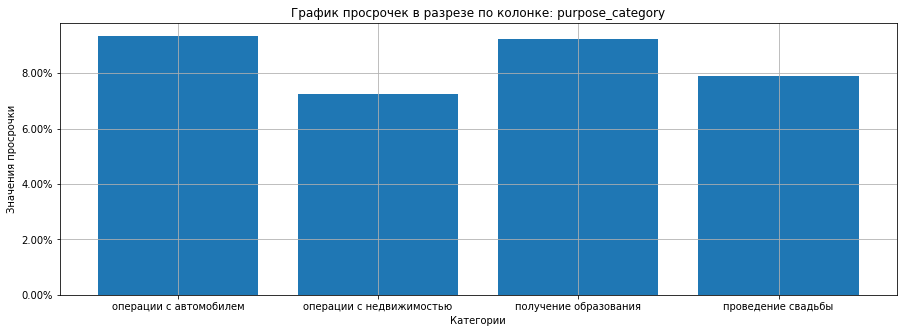

In [61]:
make_bar_plot(purpose_debt_relation)

**Вывод:** 

Операции с недвижимостью являются самой распространенной целью кредитования среди заемщиков, составляя 50.4% от общего количества наблюдений. Реже всего привлекают кредит на проведение свадьбы (10.84%).

При этом заемщики привлекающие средства на финансирование недвижимости и проведение свадьбы демонстрируют лучшую платежную дисциплину (просрочки в 7.26% и 7.91% случаев, соответственно), чем заемщики по кредитам на автомобиль и получение образования (9.35% и 9.25%). Можно предположить, что такое поведение заемщиков может быть обусловлено следующими причинами:

- Степень ответственности: Заемщики, привлекающие средства на недвижимость или свадьбу, могут относиться к этим событиям с большей степенью серьезности и ответственности. Покупка недвижимости или проведение свадьбы обычно являются крупными и важными решениями в жизни человека, и заемщики понимают, что просрочка платежей может иметь серьезные последствия для их жизни и будущего.

- Обеспечение займа: Кредиты, связанные с недвижимостью, обычно обеспечиваются сами объектом недвижимости, которая служит гарантией погашения кредита. То же самое может быть и для кредитов на свадьбу, где заемщики могут предоставить какие-то формы обеспечения, например, совместное имущество или поручительство. Это создает дополнительные мотивы для заемщиков выполнять свои обязательства и избегать просрочек, чтобы не потерять свое имущество или подвергнуть риску имущество поручителя.

#### 3.5 Приведите возможные причины появления пропусков в исходных данных.

*Ответ:* 

Пропуски могут появиться в исходных данных по следующим причинам:

- **Ошибки при сборе данных:** В процессе сбора данных могут возникать ошибки, например, неправильное заполнение анкет или опросников, пропуск отдельных вопросов или неправильное их интерпретация.
- **Технические проблемы:** Возможны сбои в системе, которые могут привести к потере данных или их неполной передаче. Например, программные ошибки, проблемы с интернет-соединением или аппаратные сбои.
- **Нежелание или невозможность респондентов предоставить данные:** Респонденты могут отказаться отвечать на определенные вопросы, особенно если они считают их чувствительными или неприятными. Также возможно, что респонденты не имеют доступа к нужным данным или просто не помнят нужную информацию.
- **Неполные данные:** В некоторых случаях данные могут быть собраны не полностью, например, если анкеты заполнены не до конца или отсутствует информация по определенным показателям.
- **Проблемы с интеграцией данных:** При объединении данных из разных источников могут возникать проблемы с соответствием форматов или отсутствием необходимых данных в одном из источников.
- **Политика конфиденциальности и безопасности:** Для защиты конфиденциальности данных могут быть применены меры анонимизации, что может привести к удалению или скрытию определенных данных. Также доступ к некоторым данным может быть ограничен из соображений безопасности.
- **Природа данных:** Некоторые данные могут быть сезонными или временными, и их отсутствие может быть обусловлено отсутствием наблюдений в определенные периоды времени. Также изменения в процессе сбора данных могут привести к пропускам, если некоторые показатели не были собраны на всех этапах.

#### 3.6 Объясните, почему заполнить пропуски медианным значением — лучшее решение для количественных переменных.

*Ответ:* 

Медиана является хорошим решением для заполнения пропусков в количественных переменных по нескольким причинам:

- **Устойчивость к разбросам данных:** медиана не так чувствительна к разбросу в данных. Это означает, что даже если есть несколько значений, которые сильно отличаются от других, медиана все равно будет представлять собой разумное среднее значение и не будет искажать всю прочую статистику.
- **Сохранение структуры:** заполнение пропусков медианным значением помогает сохранить общую форму распределения данных. Если заменить пропущенные значения средним значением, это может исказить распределение (сместить ту же медиану вправо или влево), особенно если данные имеют необычную форму или наличие значительных отклонений от среднего.
- **Простота использования:** заполнить пропущенные данные медианой достаточно просто и можно применить практически к любым количественным переменным с пропущенными значениями.

### Шаг 4: общий вывод.

Цель данного исследования, выполняемого по заказу кредитного отдела банка, заключается в определении влияния семейного положения и количества детей клиента на своевременное погашение кредита. Для достижения этой цели была проанализирована статистика о платежеспособности клиентов банка.

**Предобработка данных**

Для начала была выполнена предобработка данных, которая включала следующие шаги:
- Выявление пропущенных значений в столбце `total_income`. Пропуски были заполнены медианным значением дохода по работникам с соответствующим типом занятости.
- Обработка аномальных значений, таких как отрицательные значения в столбце `days_employed`. Отрицательные значения в столбце `days_employed` были исправлены на положительные.
- Удаление аномальных строк со значениями в столбце `children`. Строки, в которых встречались аномальные значения `children`, были удалены.
- Преобразование типов данных, например, замена вещественного типа данных в столбце `total_income` на целочисленный.
- Обработка неявных дубликатов в столбцах `education` и `purpose`.
- Категоризация клиентов по уровню дохода в столбце `total_income`. Клиенты банка были разбиты на 5 категорий в порядке уменьшения их ежемесячного дохода: A, B, C, D, E.

**Выводы исследования**

Проведенный анализ данных позволяет сделать следующие выводы:

1. Заёмщики с детьми в среднем существенно чаще допускают просрочки по кредитам (9.24%), чем бездетные (7.54%). Процент просрочек у семей с двумя детьми (9.45%) немного выше чем у семей с одним ребенком (9.23%). Таким образом, для клиентов с 0-2 детьми наблюдается следующая тенденция: чем больше детей, тем выше процент должников. Количество наблюдения по семьям с тремя и более детьми недостаточно, чтобы сделать заключение о наличии их связи с вероятностью просрочки.
   

2. Семейное положение заёмщиков влияет на вероятность своевременного погашения кредита. Клиенты могут быть упорядочены в порядке убывания процента допущенных просрочек следующим образом:
   - не женат / не замужем - 9.76%
   - гражданский брак - 9.31%
   - женат / замужем - 7.56%
   - в разводе - 7.06%
   - вдовец / вдова - 6.62%
   
   Клиенты, побывавшие или находящиеся в официальном браке, более ответственно подходят к погашению кредитов, чем клиенты в незарегистрированных отношениях.Расположение категорий заемщиков по семейному положению в таком порядке может быть связано с возрастом заемщика в соответствующей категории. Самые молодые клиенты находятся в категории «не женат/не замужем», самые возрастные в категории «вдовец/вдова».
   

3. Уровень дохода влияет на вероятность возврата кредита в срок. Абсолютное большинство клиентов (98%) приходятся всего на две категории B и C, при этом плательщики с более высокими доходами из группы B в среднем более надежны чем клиенты из категории С.  Количество наблюдения по другим категориям доходов недостаточно, чтобы сделать заключение о наличии связи с вероятностью просрочки.
   
   Если упорядочить клиентов по уровню их доходов, то клиенты из самой нижней и двух самых верхних децилей в среднем более надежны, чем клиенты из всех остальных групп.
   

4. Цель кредита влияет на вероятность возврата кредита в срок. Операции с недвижимостью являются самой распространенной целью кредитования среди заемщиков, составляя 50.4% от общего количества наблюдений. Реже всего привлекают кредит на проведение свадьбы (10.84%).
   
   Заёмщики, берущие кредит на недвижимость или свадьбу, реже допускают просрочки, чем заемщики по автокредитам и кредитам на образование. Это может быть связано с большей ответственностью заемщиков, т.к. покупка недвижимости или проведение свадьбы обычно являются крупными и важными решениями в жизни людей, и заемщики понимают, что просрочка платежей может иметь серьезные последствия для их жизни и будущего.

**Портреты надежного и рискованного заемщика**

На основе сделанных выводов можно составить портреты надежного и рискованного заёмщиков:

_Надежный заёмщик:_
- Семейное положение: состоит или состоял в официальном браке.
- Количество детей: нет детей.
- Доход: выше среднего (категории B).
- Цель займа: операции с недвижимостью.

_Рискованный заёмщик:_
- Семейное положение: не женат / не замужем.
- Количество детей: 2 и более детей.
- Доход: ниже среднего (Категория С).
- Цель займа: операции с автомобилем.

**Рекомендации по результатам исследования**

На основе выявленных зависимостей рекомендуется следующее:

1. Установить и устранить причины появления пропусков и аномалий в данных. Так, например, около 10% записей не содержит данных о доходах клиентов, что в будущем может вносить существенные погрешности в результаты проводимых исследований.

2. Используя полученные данные, можно улучшить скоринговую систему для оценки платежеспособности заемщиков. Включение факторов, таких как семейное положение, количество детей и уровень дохода, поможет более точно определить риски и принимать обоснованные решения о выдаче кредита.

3. Исследование показало, что семейное положение, количество детей, уровень дохода и цель кредита влияют на вероятность своевременного погашения кредита. Рекомендуется разработать/адаптировать политику кредитования банка, учитывая эти факторы. Например, можно предоставлять более выгодные условия кредитования для клиентов, состоящих в официальном браке и без детей, с высоким уровнем дохода и целью кредита, связанной с недвижимостью.

4. Для более глубокого понимания влияния различных факторов на погашение кредитов рекомендуется провести дополнительные исследования. Например, можно изучить взаимосвязь между сроком кредита и вероятностью просрочки или проанализировать другие социально-демографические переменные, такие как образование или возраст заемщика.

**Ограничения исследования**

При выполнении исследования были выявлены следующие ограничения:

- Данные, используемые в исследовании, предоставлены единственным банком и могут не полностью отражать общую популяцию заёмщиков.

- В исследовании не учитывались другие факторы, такие как кредитная история и уровень образования заёмщиков, которые также могут влиять на платежеспособность.

- Анализ был выполнен на основе статистических методов, что может не учитывать все возможные взаимосвязи и зависимости.

- Рекомендации, предложенные в исследовании, не являются окончательными и требуют дополнительной проверки и адаптации под конкретные условия банка.